In [47]:
path = '/home/user/Desktop/diploma'

In [48]:
import sqlite3
import os
import pandas as pd
import re
from difflib import SequenceMatcher

In [49]:
import sys
sys.path.append(os.path.abspath(path+'/results'))
from utils.metrics import evidence_evaluation

In [50]:
def extract_words(explain_prompt):

    pattern = r"List ONLY the words as a comma separated list\.\s*(.*?)\s*Generation Step:"
    match = re.search(pattern, explain_prompt, re.DOTALL | re.IGNORECASE)
    
    crucial_words = set()
    if match:
        text = match.group(1)
        # Find first comma
        first_comma = text.find(',')
        if first_comma != -1:
            # Take text before first comma → keep only last word
            prefix = text[:first_comma]
            if prefix.strip().split():
                last_word = prefix.strip().split()[-1]
                # Rebuild string: last_word + rest
                text = last_word + text[first_comma:]
                # Normalize: keep only alphanumerics and commas
                text = re.sub(r"[^a-z0-9, ]+", "", text)
                # Split into list
                for chunk in text.split(","):
                    words = chunk.strip().split()
                    crucial_words.update(words)
    if crucial_words:
        return list(crucial_words)
    else:
        return None

In [65]:
# Helper functions to eliminate code repetition

def load_model_data(model, task):
    """Load data for a specific model and task"""
    conn = sqlite3.connect(os.path.join(path, f'introspections/results/analysis/analysis_m-{model}_y-none_d-{task}_p-test_t-counterfactual_c-e-chain-of-thought_s-0.sqlite'))
    df = pd.read_sql_query("SELECT * FROM Counterfactual", conn)
    conn.close()
    return df

def get_model_info(model):
    """Extract family and size information from model name"""
    family = model.split('-')[0].capitalize()
    size = float(model.split('-')[1].replace('b', ''))
    if family == 'Qwen' and size == 1.0:
        size = 1.5  # Adjusting size for Qwen-1B to 1.5B for consistency
    return family, size

def get_original_text(debug_text, task):
    """Extract original text based on task type"""
    if debug_text is None or pd.isna(debug_text):
        return None
    
    original_text = debug_text
    if task == 'rte':
        if 'Paragraph: ' not in debug_text:
            return None
        original_text = debug_text.split('Paragraph: ')[1]
    
    return original_text

def create_precision_plot(results_df, suptitle):
    """Create standardized precision plots for both model families"""
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    families = [('Llama3', 'Llama3 Family'), ('Qwen', 'Qwen2.5 Family')]
    
    # Keep track of handles and labels for shared legend
    handles, labels = [], []
    
    for ax, (family_key, family_title) in zip(axes, families):
        family_data = results_df[results_df['family'] == family_key]
        
        if not family_data.empty:
            for task in ['imdb', 'rte']:
                task_data = family_data[family_data['task'] == task]
                if not task_data.empty:
                    color = 'blue' if task == 'imdb' else 'red'
                    if task == 'rte':
                        label = 'e-SNLI'
                    elif task == 'imdb':
                        label = 'Movie Reviews'
                    line = ax.plot(task_data['size'], task_data['precision'], 'o-', 
                           color=color, linewidth=2, markersize=8, label=label)
                    
                    # Collect handles and labels for shared legend (only from first axis)
                    if ax == axes[0] and label not in labels:
                        handles.extend(line)
                        labels.append(label)
                    
                    # Add value labels
                    for _, row in task_data.iterrows():
                        ax.annotate(f'{row["precision"]:.3f}', 
                                   (row['size'], row['precision']), 
                                   textcoords="offset points", 
                                   xytext=(0,10), 
                                   ha='center', fontsize=9)
            
            ax.set_title(family_title, fontsize=14)
            ax.set_xlabel('Model Size (Billions of Parameters)')
            ax.set_ylabel('Precision')
            ax.set_xscale('log')
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0, 1)
    
    # Add shared legend
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=2)
    
    plt.suptitle(suptitle, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()
    
    return fig

def process_models(models, precision_function, suptitle):
    """Generic function to process models and create plots"""
    results = []
    
    for model in models:
        for task in ['imdb', 'rte']:
            try:
                df = load_model_data(model, task)
                precision = precision_function(task, df)
                family, size = get_model_info(model)
                
                results.append({
                    'model': model,
                    'family': family,
                    'size': size,
                    'task': task,
                    'precision': precision
                })
                
                #print(f"{model} ({task}): {precision:.3f}")
                
            except Exception as e:
                print(f"Error with {model} ({task}): {e}")
    
    # Create DataFrame and plot
    results_df = pd.DataFrame(results)
    create_precision_plot(results_df, suptitle)
    
    return results_df

In [66]:
llama_family = ['llama3-1b','llama3-3b','llama3-8b','llama3-70b']
qwen_family = ['qwen-1b','qwen-3b','qwen-7b','qwen-14b','qwen-32b', 'qwen-72b']
models = llama_family + qwen_family

# Identification Precision

In [67]:
def identification_precision(task, df):

    total_precision = 0
    valid_samples = 0
    
    for i in range(len(df)):
        try:
            # Get original text using helper function
            original_text = get_original_text(df.iloc[i]['debug'], task)
            if original_text is None:
                continue

            # Get crucial words using existing extract_words function
            explain_prompt = df.iloc[i]['explain_prompt']
            if explain_prompt is None or pd.isna(explain_prompt):
                continue
                
            crucial_words = extract_words(explain_prompt)
            if not crucial_words:
                continue
                
            # Get modified text
            modified_text = df.iloc[i]['explain']
            if modified_text is None or pd.isna(modified_text):
                continue
            
            # Use regex to extract words (alphanumeric only)
            original_words = re.findall(r"[a-z0-9]+", original_text.lower())
            modified_words = re.findall(r"[a-z0-9]+", modified_text.lower())
            
            # Find which words were actually modified
            seq_matcher = SequenceMatcher(None, original_words, modified_words)
            modified_word_list = []
            
            for tag, i1, i2, j1, j2 in seq_matcher.get_opcodes():
                if tag == 'replace':
                    # Words that were replaced
                    modified_word_list.extend(original_words[i1:i2])
                elif tag == 'delete':
                    # Words that were deleted
                    modified_word_list.extend(original_words[i1:i2])
                elif tag == 'insert':
                    # New words that were inserted
                    modified_word_list.extend(modified_words[j1:j2])
            
            if len(modified_word_list) > 0:
                # Count how many modified words were also in crucial words
                modified_and_crucial = 0
                for word in modified_word_list:
                    if word in crucial_words:
                        modified_and_crucial += 1
                
                precision = modified_and_crucial / len(modified_word_list)
                total_precision += precision
                valid_samples += 1
                    
        except Exception as e:
            continue
    
    if valid_samples == 0:
        return 0.0
        
    return total_precision / valid_samples

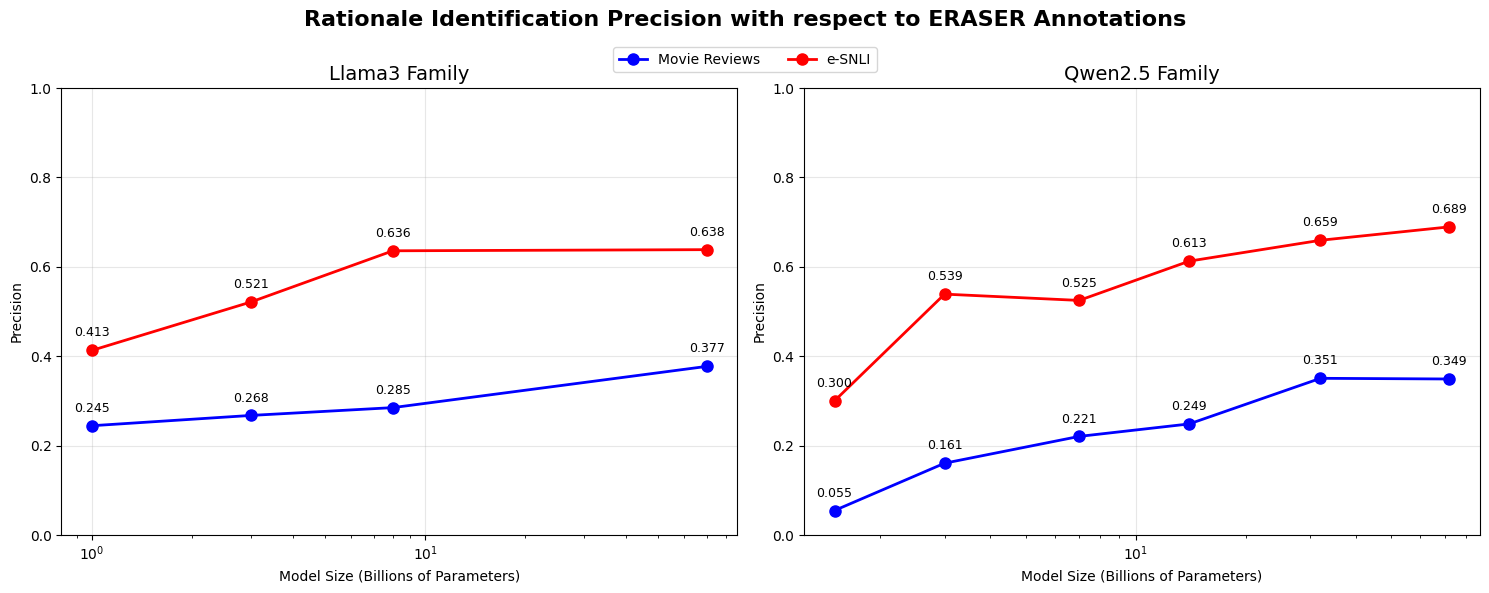

,model,family,size,task,precision
0,llama3-1b,Llama3,1.0,imdb,0.244688
1,llama3-1b,Llama3,1.0,rte,0.413227
2,llama3-3b,Llama3,3.0,imdb,0.267703
3,llama3-3b,Llama3,3.0,rte,0.521448
4,llama3-8b,Llama3,8.0,imdb,0.285163
5,llama3-8b,Llama3,8.0,rte,0.635906
6,llama3-70b,Llama3,70.0,imdb,0.377385
7,llama3-70b,Llama3,70.0,rte,0.638458
8,qwen-1b,Qwen,1.5,imdb,0.055064
9,qwen-1b,Qwen,1.5,rte,0.300344


In [68]:
process_models(
    models, 
    identification_precision,
    'Rationale Identification Precision with respect to ERASER Annotations'
)


# Generation Precision

In [69]:
def generation_precision(task, df):
    summ = 0
    valid_samples = 0
    extr_error = 0
    intr_error = 0
    
    for i in range(len(df)):  # Process all samples
        try:
            # Get original text using helper function
            original_text = get_original_text(df.iloc[i]['debug'], task)
            original_text = re.sub(r"[^\w\s]", "", original_text)

            if original_text is None:
                intr_error += 1
                continue

            # Get the crucial words list from explain_prompt
            explain_prompt = df.iloc[i]['explain_prompt']
            if explain_prompt is None or pd.isna(explain_prompt):
                continue

            crucial_words = extract_words(explain_prompt)
            
            if crucial_words:
                # Get modified/generated text from explain
                modified_text = df.iloc[i]['explain']
                modified_text = re.sub(r"[^\w\s]", "", modified_text)
                if modified_text is None or pd.isna(modified_text):
                    intr_error += 1
                    continue
                
                # Use regex to extract words (alphanumeric only) - same as identification_precision
                original_words = re.findall(r"[a-z0-9]+", original_text.lower())
                modified_words = re.findall(r"[a-z0-9]+", modified_text.lower())
                
                # Find which words were actually modified
                seq_matcher = SequenceMatcher(None, original_words, modified_words)
                modified_word_list = []
                
                for tag, i1, i2, j1, j2 in seq_matcher.get_opcodes():
                    if tag == 'replace':
                        # Words that were replaced
                        modified_word_list.extend(original_words[i1:i2])
                    elif tag == 'delete':
                        # Words that were deleted
                        modified_word_list.extend(original_words[i1:i2])
                    elif tag == 'insert':
                        # New words that were inserted
                        modified_word_list.extend(modified_words[j1:j2])
                
                if len(modified_word_list) > 0:
                    # Count how many modified words were also in crucial words
                    modified_and_crucial = 0
                    for word in modified_word_list:
                        if word in crucial_words and len(word)>1:
                            modified_and_crucial += 1
                    
                    precision = modified_and_crucial / len(modified_word_list)
                    summ += precision
                    valid_samples += 1
            else:
                extr_error += 1
                
        except Exception as e:
            intr_error += 1
            continue
    
    if valid_samples == 0:
        return 0.0

    return summ / valid_samples

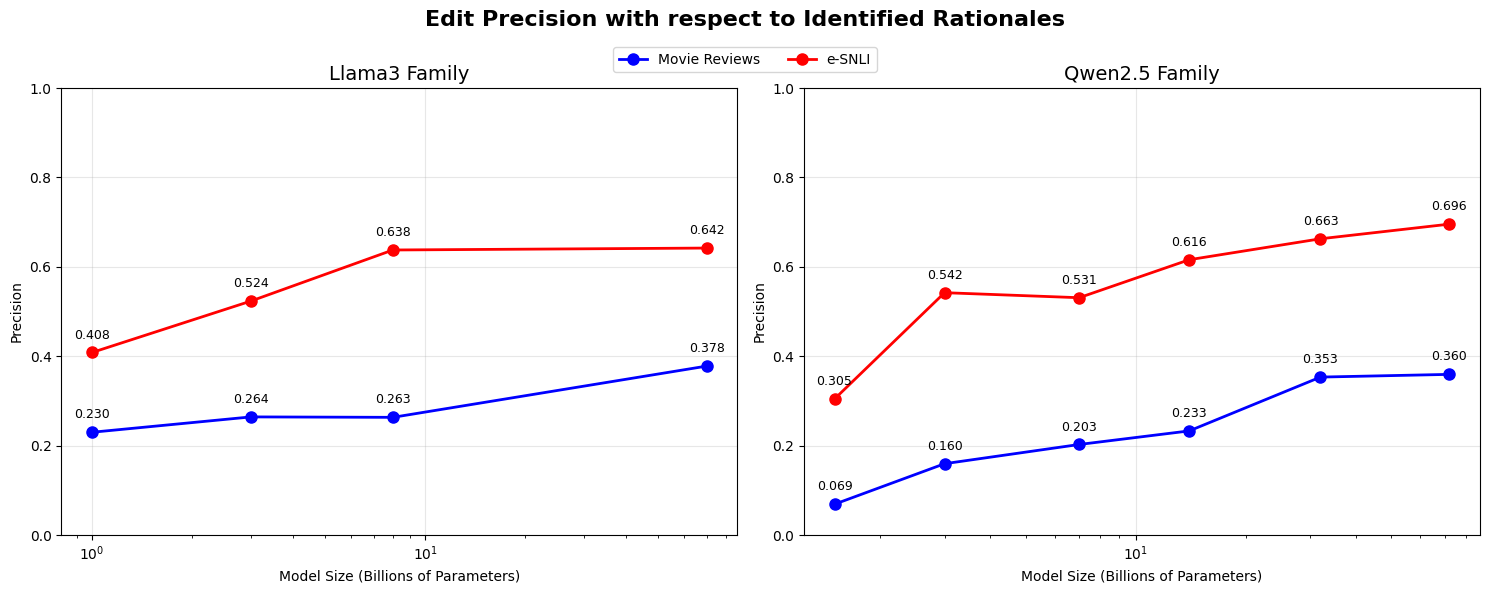

,model,family,size,task,precision
0,llama3-1b,Llama3,1.0,imdb,0.230057
1,llama3-1b,Llama3,1.0,rte,0.408446
2,llama3-3b,Llama3,3.0,imdb,0.264407
3,llama3-3b,Llama3,3.0,rte,0.523524
4,llama3-8b,Llama3,8.0,imdb,0.263428
5,llama3-8b,Llama3,8.0,rte,0.637713
6,llama3-70b,Llama3,70.0,imdb,0.378074
7,llama3-70b,Llama3,70.0,rte,0.642016
8,qwen-1b,Qwen,1.5,imdb,0.069119
9,qwen-1b,Qwen,1.5,rte,0.304527


In [70]:
process_models(
    models, 
    generation_precision,
    'Edit Precision with respect to Identified Rationales'
)